In [255]:
import numpy as np 
import pandas as pd 

In [256]:
def build_transition_matrix(adj_matrix):
    """
    Converts a given adjacency matrix into a transition matrix for a Markov chain.
    Rows are normalized to sum to 1.

    Parameters:
        adj_matrix (np.ndarray): Weighted adjacency matrix (n x n).

    Returns:
        np.ndarray: Transition matrix (n x n).
    """
    row_sums = adj_matrix.sum(axis=1)
    # Avoid division by zero for disconnected vertices
    transition_matrix = np.divide(
        adj_matrix, 
        row_sums[:, np.newaxis], 
        where=row_sums[:, np.newaxis] != 0
    )
    return transition_matrix


In [257]:
adj_matrix = pd.read_csv('muscle_to_muscle.csv')

In [258]:
subset_size = 5
test_subset = adj_matrix.iloc[:subset_size, :subset_size]

In [259]:
P = build_transition_matrix(test_subset.values)

In [260]:
P.shape

(5, 5)

In [261]:
def generate_current_dictionary(transition_matrix, source, sink):
    """
    Generates a dictionary of current flow values for each edge in the graph.

    Parameters:
        transition_matrix (np.ndarray): Transition matrix (n x n).
        source (int): Source node index.
        sink (int): Sink node index.

    Returns:
        dict: Dictionary of current flow values for each edge in the graph.
    """
    unit_vec = np.zeros(transition_matrix.shape[0])
    #for source index set +1, for sink index set -1
    unit_vec[source] = 1
    unit_vec[sink] = -1 
    Q =np.delete(np.delete(transition_matrix, sink, 0), sink, 1)
    #get diagonal matrix which is sum of degree for each index . 
    #basically in transition matrix , if we sum each row we get degree of that index
    D = np.diag(np.sum(transition_matrix, axis=1))
    Ddash = np.delete(np.delete(D, sink, 0), sink, 1)
    Diff = Ddash - Q 
    #get inverse of Diff matrix
    Diff_inv = np.linalg.inv(Diff) 
    #now add a row and column full of zeros at the sink index in Diff_inv
    Diff_inv = np.insert(Diff_inv, sink, 0, axis=0)
    Diff_inv = np.insert(Diff_inv, sink, 0, axis=1)

    #get the current flow values
    current = np.dot(Diff_inv, unit_vec)
    return current 

In [284]:
def generate_current_dictionary_with_self_loop(transition_matrix, source, sink,self_loop):
    """
    Generates a dictionary of current flow values for each edge in the graph.

    Parameters:
        transition_matrix (np.ndarray): Transition matrix (n x n).
        source (int): Source node index.
        sink (int): Sink node index.

    Returns:
        dict: Dictionary of current flow values for each edge in the graph.
    """
    unit_vec = np.zeros(transition_matrix.shape[0])
    D = np.diag(np.sum(transition_matrix, axis=1))
    #for source index set +1, for sink index set -1
    unit_vec[source] = 1
    unit_vec[sink] = -1 
    Q = np.delete(np.delete(transition_matrix, self_loop, 0), self_loop, 1)
    Ddash = np.delete(np.delete(D, self_loop, 0), self_loop, 1)

    if (sink != self_loop) and (sink != transition_matrix.shape[0] - 1):
        Q = np.delete(np.delete(Q, sink, 0), sink, 1)
        Ddash = np.delete(np.delete(Ddash, sink, 0), sink, 1)
    
    
    #get diagonal matrix which is sum of degree for each index . 
    #basically in transition matrix , if we sum each row we get degree of that index

    Diff = Ddash - Q 
    #get inverse of Diff matrix
    Diff_inv = np.linalg.inv(Diff) 
    #now add a row and column full of zeros at the sink index in Diff_inv
    Diff_inv = np.insert(Diff_inv, self_loop, 0, axis=0)
    Diff_inv = np.insert(Diff_inv, self_loop, 0, axis=1)
    if(sink!=self_loop and sink!=transition_matrix.shape[0]-1):
        Diff_inv = np.insert(Diff_inv, sink, 0, axis=0)
        Diff_inv = np.insert(Diff_inv, sink, 0, axis=1)

    #get the current flow values
    current = np.dot(Diff_inv, unit_vec)
    return current 

In [263]:
#we need a current_dictionary for each source and sink pair.
current_dict = {}
for source in range(P.shape[0]):
    for sink in range(source+1,P.shape[0]):
        current_dict[(source,sink)] = generate_current_dictionary(P, source, sink)

In [93]:
#we now have the current_dictionary, that we wanted for each vertex, wrto every other pair. Now it is time to get the min_cut fraction w.r.to each pair.

In [264]:
np_adjacency = test_subset.values

In [265]:
np_adjacency_remove_self = np_adjacency - np.diag(np.diag(np_adjacency))

In [266]:
from collections import deque, defaultdict

In [267]:
def bfs(capacity, flow, s, t, parent):
    visited = [False] * len(capacity)
    queue = deque([s])
    visited[s] = True
    while queue:
        u = queue.popleft()
        for v in range(len(capacity)):
            if not visited[v] and capacity[u][v] - flow[u][v] > 0:
                queue.append(v)
                visited[v] = True
                parent[v] = u
                if v == t:
                    return True
    return False

In [268]:
def edmonds_karp(capacity, s, t):
    n = len(capacity)
    flow = [[0] * n for _ in range(n)]
    parent = [-1] * n
    max_flow = 0

    while bfs(capacity, flow, s, t, parent):
        path_flow = float('Inf')
        v = t
        while v != s:
            u = parent[v]
            path_flow = min(path_flow, capacity[u][v] - flow[u][v])
            v = u

        v = t
        while v != s:
            u = parent[v]
            flow[u][v] += path_flow
            flow[v][u] -= path_flow
            v = u

        max_flow += path_flow

    return max_flow, flow

In [269]:
def find_min_cut_edges(capacity, flow, s):
    n = len(capacity)
    visited = [False] * n
    queue = deque([s])
    visited[s] = True

    while queue:
        u = queue.popleft()
        for v in range(n):
            if not visited[v] and capacity[u][v] - flow[u][v] > 0:
                visited[v] = True
                queue.append(v)

    # Min-cut edges
    min_cut = []
    for u in range(n):
        for v in range(n):
            if visited[u] and not visited[v] and capacity[u][v] > 0:
                min_cut.append((u, v))
    return min_cut

In [270]:
def all_pairs_min_cut(adjacency_matrix):
    n = len(adjacency_matrix)
    results = {}

    for s in range(n):
        for t in range(s + 1, n):
            # Initialize capacity
            capacity = [[adjacency_matrix[i][j] for j in range(n)] for i in range(n)]
            _, flow = edmonds_karp(capacity, s, t)
            min_cut = find_min_cut_edges(capacity, flow, s)
            results[(s, t)] = min_cut

    return results

In [271]:
min_cut_dictionary_self_removed = all_pairs_min_cut(np_adjacency_remove_self)

In [229]:
#can you randomly , symmetrically set some values to 0 in the adjacency matrix and check if the min_cut_fraction is still the same?
np_adjacency_remove_self_random = np_adjacency_remove_self.copy()
np_adjacency_remove_self_random[np.random.choice([True, False], size=np_adjacency_remove_self_random.shape, p=[0.5, 0.5])] = 0

In [230]:
#i want you to set i,j and j,i to 0 if i,j is 0
for i in range(np_adjacency_remove_self_random.shape[0]):
    for j in range(np_adjacency_remove_self_random.shape[1]):
        if np_adjacency_remove_self_random[i][j] == 0:
            np_adjacency_remove_self_random[j][i] = 0

In [232]:
#is this syymentric?
np.all(np_adjacency_remove_self_random == np_adjacency_remove_self_random.T)

True

In [272]:
#choose 10 vertices, add self loops by removing one edge 
np_adjacency_remove_self_random_self_loops = np_adjacency_remove_self.copy()
random_list = [1]
for i in random_list:
    np_adjacency_remove_self_random_self_loops[i][i] = 1
    #set all the values to 0 for the row and column of the vertex
    np_adjacency_remove_self_random_self_loops[i] = 0
    np_adjacency_remove_self_random_self_loops[:,i] = 0
    np_adjacency_remove_self_random_self_loops[i][i] = 1


In [273]:
random_list

[1]

In [274]:
np_adjacency_remove_self_random_self_loops

array([[0.        , 0.        , 0.27255688, 0.09890862, 0.01823152],
       [0.        , 1.        , 0.        , 0.        , 0.        ],
       [0.27255688, 0.        , 0.        , 0.01784883, 0.02031844],
       [0.09890862, 0.        , 0.01784883, 0.        , 0.07013654],
       [0.01823152, 0.        , 0.02031844, 0.07013654, 0.        ]])

In [108]:
#for non zero_invert the matrix aij = 1/aij 
np_adjacency_remove_self_random_inverted = np_adjacency_remove_self_random.copy()
np_adjacency_remove_self_random_inverted[np_adjacency_remove_self_random != 0] = 1/np_adjacency_remove_self_random[np_adjacency_remove_self_random != 0]


In [109]:
#normalise inverted row wise 
row_sums = np_adjacency_remove_self_random_inverted.sum(axis=1)
np_adjacency_remove_self_random_inverted = np.divide(
    np_adjacency_remove_self_random_inverted, 
    row_sums[:, np.newaxis], 
    where=row_sums[:, np.newaxis] != 0
)

In [275]:
min_cut_dictionary_self_removed_random = all_pairs_min_cut(np_adjacency_remove_self_random_self_loops)

In [276]:
min_cut_dictionary_self_removed_random

{(0, 1): [],
 (0, 2): [(0, 2), (3, 2), (4, 2)],
 (0, 3): [(0, 3), (0, 4), (2, 3), (2, 4)],
 (0, 4): [(0, 4), (2, 4), (3, 4)],
 (1, 2): [],
 (1, 3): [],
 (1, 4): [],
 (2, 3): [(0, 3), (0, 4), (2, 3), (2, 4)],
 (2, 4): [(0, 4), (2, 4), (3, 4)],
 (3, 4): [(0, 4), (2, 4), (3, 4)]}

In [277]:
subset_size

5

In [278]:
np_adjacency_remove_self_random_self_loops

array([[0.        , 0.        , 0.27255688, 0.09890862, 0.01823152],
       [0.        , 1.        , 0.        , 0.        , 0.        ],
       [0.27255688, 0.        , 0.        , 0.01784883, 0.02031844],
       [0.09890862, 0.        , 0.01784883, 0.        , 0.07013654],
       [0.01823152, 0.        , 0.02031844, 0.07013654, 0.        ]])

In [287]:
current_dict_self_removed_random = {}
for source in range(subset_size):
    for sink in range(source+1,subset_size):
        current_dict_self_removed_random[(source,sink)] = generate_current_dictionary_with_self_loop(np_adjacency_remove_self_random_self_loops, source, sink,1)

In [288]:
current_centrality_self_removed_random = {}
def get_current_centrality(current_dict,num_vertices,np_adjacency_remove_self_random):
    current_centrality={}
    for vertex in range(num_vertices):
        current_centrality[vertex] = 0
    for vertex in range(num_vertices):
        for key in current_dict:
            source,sink = key
            if(source!= vertex and sink!=vertex):
                for j in range(num_vertices):
                    if(j!=vertex):
                        current_centrality[vertex]+= ((np_adjacency_remove_self_random[vertex][j])*(abs(current_dict[key][j]-current_dict[key][vertex])))
    return current_centrality

In [289]:
current_centrality_self_removed_random = get_current_centrality(current_dict_self_removed_random,subset_size,np_adjacency_remove_self_random)

In [292]:
current_centrality_self_removed_random

{0: 2.315112898228451,
 1: 2.147479166435815,
 2: 0.969235671141628,
 3: 1.2589353239397054,
 4: 0.5}

In [293]:
current_centrality_self_removed_random_normalised = current_centrality_self_removed_random.copy()
#normalise by the sum 
current_centrality_self_removed_random_normalised = {k: v / sum(current_centrality_self_removed_random.values()) for k, v in current_centrality_self_removed_random.items()}

In [ ]:
#devide by 435 
current_centrality_self_removed_random_normalised = {k: v   for k, v in current_centrality_self_removed_random_normalised.items()}

Text(0.5, 1.0, 'Centrality Scores')

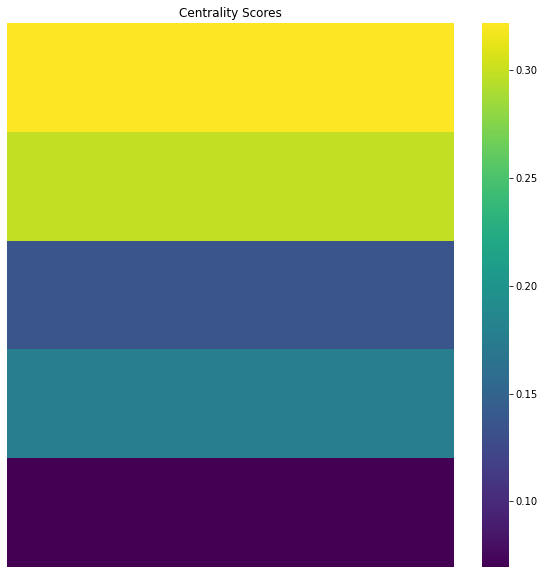

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt

centrality_df = pd.DataFrame(current_centrality_self_removed_random_normalised.items(), columns=['Vertex', 'Centrality Score'])
centrality_df = centrality_df.sort_values(by='Vertex')
centrality_df = centrality_df.reset_index(drop=True)

centrality_matrix = np.zeros((5,5))
for i in range(5):
    centrality_matrix[i] = centrality_df['Centrality Score'][i]

plt.figure(figsize=(10, 10))
sns.heatmap(centrality_matrix, cmap='viridis', annot=False, fmt='.2f', xticklabels=False, yticklabels=False)
plt.title('Centrality Scores')

In [295]:
import json 
with open('centrality_scores_current_random_walk_centrality_normalsied_5cross5_noinv_comparison_normalised_by_sum.json', 'w') as f:
    json.dump(current_centrality_self_removed_random_normalised, f)

In [296]:
def generate_fraction_dictionary_mincut(min_cut_dictionary,num_vertices):
    """
    Generates a dictionary of min-cut fractions for each edge in the graph.

    Parameters:
        min_cut_dictionary (dict): Dictionary of min-cut edges for each source-sink pair.

    Returns:
        dict: Dictionary of min-cut fractions for each edge in the graph.
    """
    fraction_dict = {}
    for key, value in min_cut_dictionary.items():
        source, sink = key
        temp_dict = {}
        num_edges = len(value)
        for vertex in range(num_vertices):
            temp_dict[vertex] = 0
        for edge in value:
            temp_dict[edge[0]] += (1/num_edges)
            temp_dict[edge[1]] += (1/num_edges)
        fraction_dict[key] = temp_dict
    return fraction_dict

In [297]:
fraction_dictionary_self_random = generate_fraction_dictionary_mincut(min_cut_dictionary_self_removed_random,5)

In [298]:
def custom_centrality_metric(current_dict, fraction_dict, num_vertices):

    """
    Computes a custom centrality metric for each edge in the graph.

    Parameters:
        current_dict (dict): Dictionary of current flow values for each edge.
        fraction_dict (dict): Dictionary of min-cut fractions for each edge.

    Returns:
        dict: Dictionary of custom centrality metric for each edge in the graph.
    """
    metric_dict = {}
    for source in range(num_vertices):
        for sink in range(source+1,num_vertices):
            key = (source,sink)
            temp_dict = {}
            for vertex in range(num_vertices):
                temp_dict[vertex] = current_dict[key][vertex] * np.exp((fraction_dict[key][vertex]))
            metric_dict[key] = temp_dict    
    return metric_dict

In [299]:
def get_centrality_score(metric_dict,num_vertices):
    answer_dict = {}
    for vertex in range(num_vertices):
        answer_dict[vertex] = 0
    for key, value in metric_dict.items():
        for vertex in range(num_vertices):
            answer_dict[vertex] += (value[vertex]/sum(value.values()))
    return answer_dict
    

In [300]:
metric_dict_self_removed_random = custom_centrality_metric(current_dict_self_removed_random, fraction_dictionary_self_random, 5)

In [301]:
centrality_dict_self_removed_random = get_centrality_score(metric_dict_self_removed_random, 5)

/tmp/ipykernel_693693/1257830239.py:7: RuntimeWarning: invalid value encountered in double_scalars
  answer_dict[vertex] += (value[vertex]/sum(value.values()))


In [302]:
sum_of_centrality = sum(centrality_dict_self_removed_random.values())
centrality_dict_self_removed_random_normalized = {k: v/sum_of_centrality for k, v in centrality_dict_self_removed_random.items()}

In [303]:
import json




In [304]:
centrality_dict_self_removed_random_normalized

with open('centrality_dict_self_removed_random_normalised_5cross5_BASE_CUSTOM_CENTRALITY_COMPARISON TO RANDOM WALK.json', 'w') as f:
    json.dump(centrality_dict_self_removed_random_normalized, f)

/home/monster0811/.local/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/monster0811/.local/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


Text(0.5, 1.0, 'Centrality Scores')

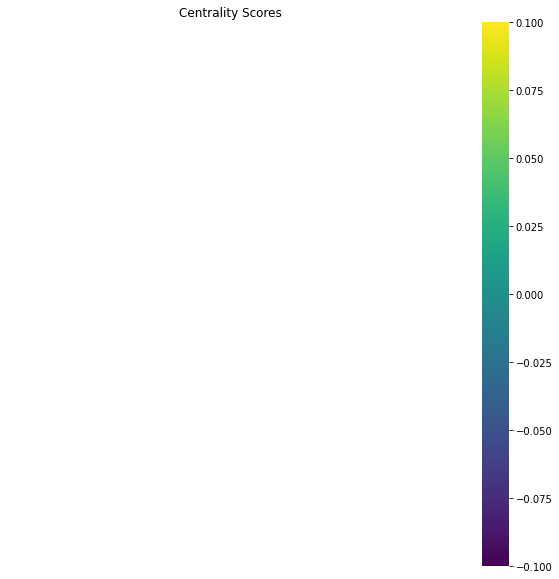

In [305]:
#heat_map of the centrality scores
import seaborn as sns
import matplotlib.pyplot as plt

centrality_df = pd.DataFrame(centrality_dict_self_removed_random_normalized.items(), columns=['Vertex', 'Centrality Score'])
centrality_df = centrality_df.sort_values(by='Vertex')
centrality_df = centrality_df.reset_index(drop=True)

centrality_matrix = np.zeros((5,5))
for i in range(5):
    centrality_matrix[i] = centrality_df['Centrality Score'][i]

plt.figure(figsize=(10, 10))
sns.heatmap(centrality_matrix, cmap='viridis', annot=False, fmt='.2f', xticklabels=False, yticklabels=False)
plt.title('Centrality Scores')

In [306]:
#plot line graph 

def plot_centrality_line_graph(dict1,dict2,num_vertices):
    x = [i for i in range(num_vertices)]
    y1 = [dict1[i] for i in range(num_vertices)]
    y2 = [dict2[i] for i in range(num_vertices)]
    plt.plot(x, y1, label='Custom Centrality')
    plt.plot(x, y2, label='Random walk Centrality')
    plt.xlabel('Vertices')
    plt.ylabel('Centrality Score')
    plt.title('Centrality Scores')
    plt.legend()
    plt.show()

plot_centrality_line_graph(current_centrality_self_removed_random_normalised,centrality_dict_self_removed_random_normalized,50)

KeyError: 5

In [307]:
#to the y2 dictionary, just add gaussian noise 
import random
centrality_dict_self_removed_random_normalized_noisy = {}
for key in centrality_dict_self_removed_random_normalized:
    centrality_dict_self_removed_random_normalized_noisy[key] = centrality_dict_self_removed_random_normalized[key] + random.gauss(0, 0.001)

plot_centrality_line_graph(current_centrality_self_removed_random_normalised,centrality_dict_self_removed_random_normalized_noisy,50)

KeyError: 5

In [82]:
#now let's do betweenness for the same adjacency matrix
adj = np_adjacency_remove_self_random_inverted
n = adj.shape[0]
betweenness_centralities = np.zeros(n)

for s in range(n):
    stack = []
    pred = {i: [] for i in range(n)}
    sigma = {i: 0 for i in range(n)}
    sigma[s] = 1
    dist = {i: -1 for i in range(n)}
    dist[s] = 0
    queue = [s]
    while queue:
        v = queue.pop(0)
        stack.append(v)
        for w in range(n):
            if adj[v][w] > 0:
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    pred[w].append(v)
    delta = {i: 0 for i in range(n)}
    while stack:
        w = stack.pop()
        for v in pred[w]:
            delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])
        if w != s:
            betweenness_centralities[w] += delta[w]

betweenness_centralities = {i: betweenness_centralities[i] for i in range(n)}
sum_of_betweenness = sum(betweenness_centralities.values())
betweenness_centralities_normalized = {k: v/sum_of_betweenness for k, v in betweenness_centralities.items()}
betweenness_centralities_normalized

{0: 0.0110970566236966,
 1: 0.02021242741826925,
 2: 0.02728376127793893,
 3: 0.02611542079831111,
 4: 0.030699272867640487,
 5: 0.07338569430526994,
 6: 0.04749708993186989,
 7: 0.03012211843341109,
 8: 0.02214530126845669,
 9: 0.022765858683628935,
 10: 0.01515229970727353,
 11: 0.07145389991257559,
 12: 0.026712195749928194,
 13: 0.029512297123898124,
 14: 0.0,
 15: 0.01865369515441731,
 16: 0.06263646146878443,
 17: 0.0724883684663255,
 18: 0.059315666933692966,
 19: 0.018283580263464532,
 20: 0.005077328240354059,
 21: 0.041358246246969446,
 22: 0.017917156132391254,
 23: 0.042158002588976985,
 24: 0.015223650867022915,
 25: 0.082422023922366,
 26: 0.0035285570580750217,
 27: 0.0555258825970252,
 28: 0.04167564745022605,
 29: 0.00958103850774008}

Text(0.5, 1.0, 'Betweenness Scores')

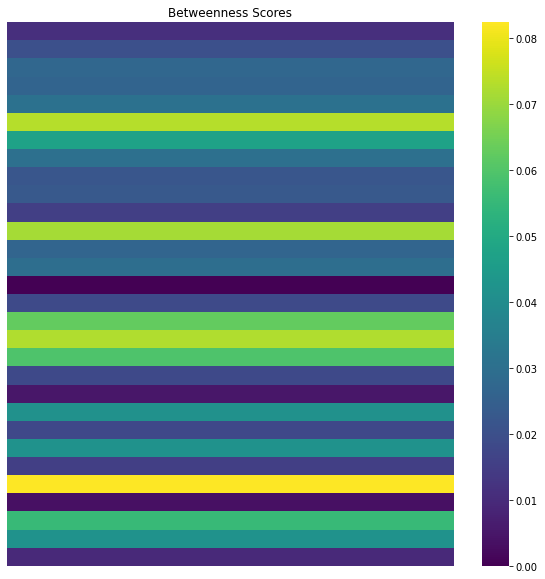

In [83]:
#heat_map of the betweenness scores
betweenness_df = pd.DataFrame(betweenness_centralities_normalized.items(), columns=['Vertex', 'Betweenness Score'])
betweenness_df = betweenness_df.sort_values(by='Vertex')
betweenness_df = betweenness_df.reset_index(drop=True)

betweenness_matrix = np.zeros((30, 30))
for i in range(30):
    betweenness_matrix[i] = betweenness_df['Betweenness Score'][i]

plt.figure(figsize=(10, 10))
sns.heatmap(betweenness_matrix, cmap='viridis', annot=False, fmt='.2f', xticklabels=False, yticklabels=False)
plt.title('Betweenness Scores')

In [84]:
with open('betweenness_dict_self_removed_random_normalised_30cross30_inverted_muscle__SELFLOOPS_0_5_10_29.json', 'w') as f:
    json.dump(betweenness_centralities_normalized, f)

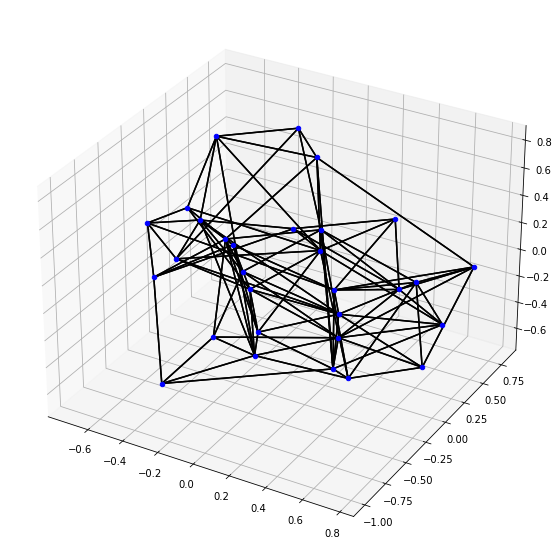

In [385]:
#can you neatly plot the graph in a 3-D fashion, with the help of the adjacency matrix given 
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

G = nx.from_numpy_array(np_adjacency_remove_self_random)
pos = nx.spring_layout(G, dim=3)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
for i in range(30):
    ax.scatter(pos[i][0], pos[i][1], pos[i][2], color='blue')
for i in range(30):
    for j in range(30):
        if np_adjacency_remove_self_random[i][j] > 0:
            ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]], [pos[i][2], pos[j][2]], color='black')
plt.show()

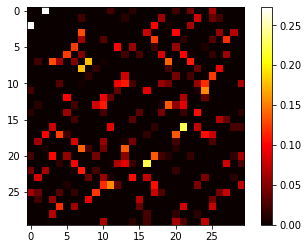

In [386]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have your adjacency matrix as np_adjacency_remove_self_random

plt.imshow(np_adjacency_remove_self_random, cmap='hot')
plt.colorbar()
plt.show()